# Multiple fiber families and spatial regularization

This notebook extends the image-informed finite-element model from a
single fiber direction to:

1. multiple discrete fiber families;
2. a quadrature approximation of a continuous orientation distribution;
3. nematic-safe spatial regularization on the element graph.

The main goals are to verify the multi-family constitutive law,
quantify the effect of orientation dispersion, and compare raw and
regularized heterogeneous tissue architectures under the same
displacement-controlled loading.

> All structural fields in this notebook are synthetic benchmarks with
> known construction rules and reproducible random seeds.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (
    FiniteElementConfig,
    MaterialParameters,
    MultiFiberMaterialParameters,
    angle_to_vector,
    discrete_nematic_coherence,
    discrete_nematic_distribution,
    element_centroids,
    multifiber_cauchy_stress,
    multifiber_first_piola_stress,
    multifiber_strain_energy_density,
    nematic_graph_roughness,
    rectangular_quad_mesh,
    regularize_nematic_field,
    regularize_scalar_field,
    scalar_graph_roughness,
    solve_multifiber_displacement_controlled_equilibrium,
    strain_energy_density,
    theoretical_nematic_coherence,
    vector_to_angle,
)

np.set_printoptions(precision=6, suppress=True)
print(f"Repository root: {REPOSITORY_ROOT}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling


## 1. Multi-family constitutive law

The fiber energy is the weighted sum

\[
\psi_f =
\sum_{m=1}^{M}
w_m\beta_m
\frac{k_{1m}}{2k_{2m}}
\left[
\exp\left(
k_{2m}\langle I_{4m}-1\rangle_+^2
\right)-1
\right],
\]

with

\[
I_{4m} =
\mathbf a_0^{(m)}\cdot\mathbf C\mathbf a_0^{(m)}.
\]

The mixture weights are normalized internally. This separates the
total fiber stiffness scale from the number of discrete families.

In [2]:
material = MultiFiberMaterialParameters(
    mu=2.0,
    kappa=80.0,
    k1=(2.2, 1.4),
    k2=(4.0, 3.5),
    family_weights=(0.65, 0.35),
)

F_check = np.array([[1.12, 0.08], [0.03, 0.94]])
family_direction_check = angle_to_vector(np.deg2rad([20.0, 105.0]))
beta_check = np.array([0.70, 0.42])

energy_check = multifiber_strain_energy_density(
    F_check,
    family_direction_check,
    beta_check,
    material,
)
P_check = multifiber_first_piola_stress(
    F_check,
    family_direction_check,
    beta_check,
    material,
)
sigma_check = multifiber_cauchy_stress(
    F_check,
    family_direction_check,
    beta_check,
    material,
)

print(f"Energy density: {float(energy_check):.9f}")
print("First Piola stress:")
print(P_check)
print("Cauchy stress:")
print(sigma_check)

Energy density: 0.193014790
First Piola stress:
[[4.787039 0.401988]
 [0.177174 4.038061]]
Cauchy stress:
[[5.134846 0.496458]
 [0.496458 3.618709]]


### 1.1 Independent finite-difference verification of
        \(\mathbf P=\partial\psi/\partial\mathbf F\)

In [3]:
epsilon = 1.0e-6
P_numerical = np.empty((2, 2))
for row in range(2):
    for column in range(2):
        perturbation = np.zeros((2, 2))
        perturbation[row, column] = epsilon
        plus = multifiber_strain_energy_density(
            F_check + perturbation,
            family_direction_check,
            beta_check,
            material,
        )
        minus = multifiber_strain_energy_density(
            F_check - perturbation,
            family_direction_check,
            beta_check,
            material,
        )
        P_numerical[row, column] = (plus - minus) / (2.0 * epsilon)

relative_error = np.linalg.norm(P_check - P_numerical) / np.linalg.norm(P_numerical)
print(f"Relative Piola error: {relative_error:.3e}")
assert relative_error < 1.0e-6
assert np.max(np.abs(sigma_check - sigma_check.T)) < 1.0e-12

Relative Piola error: 1.102e-10


### 1.2 Reduction to the original single-family model

In [4]:
original_material = MaterialParameters(
    mu=2.0,
    kappa=80.0,
    k1=2.2,
    k2=4.0,
)
single_family_material = MultiFiberMaterialParameters(
    mu=2.0,
    kappa=80.0,
    k1=(2.2,),
    k2=(4.0,),
    family_weights=(1.0,),
)
single_direction = angle_to_vector(np.deg2rad(25.0))
single_beta = 0.68

original_energy = strain_energy_density(
    F_check,
    single_direction,
    single_beta,
    original_material,
)
multi_energy = multifiber_strain_energy_density(
    F_check,
    single_direction[None, :],
    np.array([single_beta]),
    single_family_material,
)
reduction_error = abs(float(original_energy) - float(multi_energy))
print(f"Single-family reduction error: {reduction_error:.3e}")
assert reduction_error < 1.0e-12

Single-family reduction error: 0.000e+00


## 2. Discrete orientation distribution

A continuous planar orientation distribution is approximated by
quadrature directions on \([0,\pi)\). We use the nematic von Mises
density

\[
\rho(\theta)\propto
\exp[\kappa\cos 2(\theta-\bar\theta)].
\]

Its theoretical coherence is

\[
c(\kappa)=\frac{I_1(\kappa)}{I_0(\kappa)}.
\]

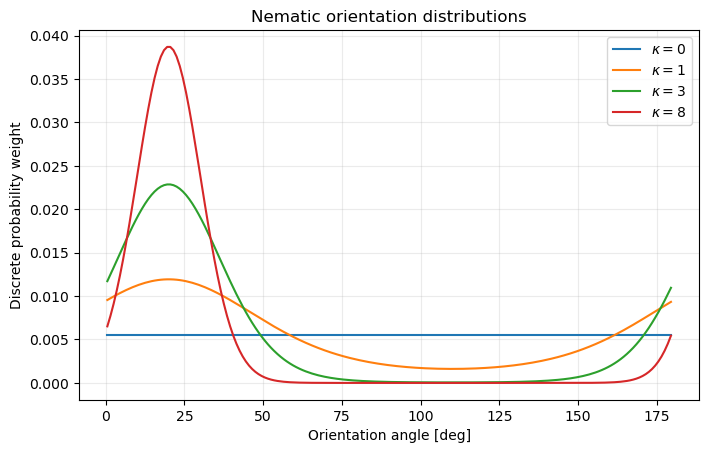

   kappa     discrete c    theoretical c
    0.00     0.00000000       0.00000000
    1.00     0.44638997       0.44638997
    3.00     0.80998529       0.80998529
    8.00     0.93523549       0.93523549


In [5]:
concentrations = [0.0, 1.0, 3.0, 8.0]
distribution_rows = []

figure, axis = plt.subplots(figsize=(8, 4.8))
for concentration in concentrations:
    angles, directions, weights = discrete_nematic_distribution(
        np.deg2rad(20.0),
        concentration,
        number_of_directions=180,
    )
    coherence_discrete = discrete_nematic_coherence(directions, weights)
    coherence_exact = theoretical_nematic_coherence(concentration)
    distribution_rows.append(
        (concentration, coherence_discrete, coherence_exact)
    )
    axis.plot(
        np.rad2deg(angles),
        weights,
        label=rf"$\kappa={concentration:g}$",
    )

axis.set(
    xlabel="Orientation angle [deg]",
    ylabel="Discrete probability weight",
    title="Nematic orientation distributions",
)
axis.grid(True, alpha=0.25)
axis.legend()
plt.show()

print(f"{'kappa':>8} {'discrete c':>14} {'theoretical c':>16}")
for row in distribution_rows:
    print(f"{row[0]:8.2f} {row[1]:14.8f} {row[2]:16.8f}")

### 2.1 Mechanical effect of orientation dispersion

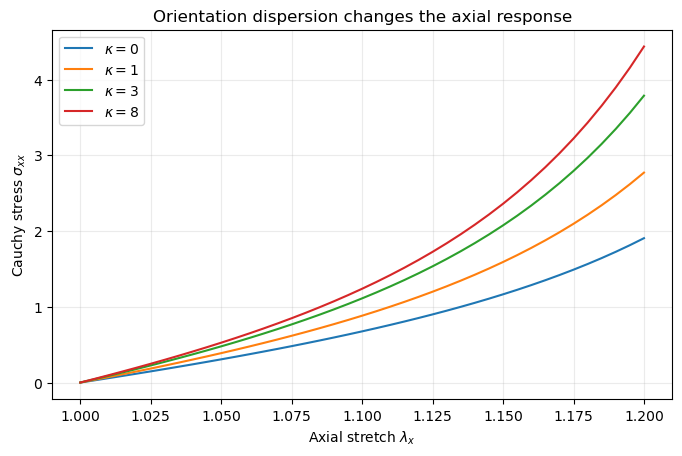

In [6]:
stretch_values = np.linspace(1.0, 1.20, 41)
distribution_stress = {}

for concentration in concentrations:
    _, directions, weights = discrete_nematic_distribution(
        0.0,
        concentration,
        number_of_directions=72,
    )
    distribution_material = MultiFiberMaterialParameters(
        mu=2.0,
        kappa=80.0,
        k1=tuple(np.full(72, 2.0)),
        k2=tuple(np.full(72, 4.0)),
        family_weights=tuple(weights),
    )
    beta_distribution = np.full(72, 0.75)
    axial_stress = []
    for stretch in stretch_values:
        deformation = np.diag([stretch, 1.0 / stretch])
        stress = multifiber_cauchy_stress(
            deformation,
            directions,
            beta_distribution,
            distribution_material,
        )
        axial_stress.append(float(stress[0, 0]))
    distribution_stress[concentration] = np.asarray(axial_stress)

figure, axis = plt.subplots(figsize=(8, 4.8))
for concentration in concentrations:
    axis.plot(
        stretch_values,
        distribution_stress[concentration],
        label=rf"$\kappa={concentration:g}$",
    )
axis.set(
    xlabel=r"Axial stretch $\lambda_x$",
    ylabel=r"Cauchy stress $\sigma_{xx}$",
    title="Orientation dispersion changes the axial response",
)
axis.grid(True, alpha=0.25)
axis.legend()
plt.show()

## 3. Synthetic two-family tissue architecture

The finite-element benchmark uses a dominant primary family and a
weaker cross-family. Pixel-scale perturbations are added
deliberately so that the effect of regularization can be measured.

In [7]:
mesh = rectangular_quad_mesh(5, 3, width=2.0, height=1.0)
centroid = element_centroids(mesh)
x = centroid[:, 0] / mesh.width
y = centroid[:, 1] / mesh.height
rng = np.random.default_rng(17)

primary_angle_true = np.deg2rad(
    25.0 + 18.0 * np.sin(np.pi * x) * np.cos(np.pi * (y - 0.5))
)
primary_angle_raw = primary_angle_true + np.deg2rad(
    rng.normal(0.0, 7.0, mesh.number_of_elements)
)
secondary_angle_raw = primary_angle_raw + np.deg2rad(72.0)
family_direction_raw = np.stack(
    (
        angle_to_vector(primary_angle_raw),
        angle_to_vector(secondary_angle_raw),
    ),
    axis=1,
)

defect = np.exp(
    -0.5
    * (
        ((x - 0.62) / 0.18) ** 2
        + ((y - 0.55) / 0.22) ** 2
    )
)
beta_raw = np.column_stack(
    (
        np.clip(
            0.72 - 0.30 * defect + rng.normal(0.0, 0.05, x.size),
            0.05,
            1.0,
        ),
        np.clip(
            0.38 - 0.12 * defect + rng.normal(0.0, 0.04, x.size),
            0.05,
            1.0,
        ),
    )
)

regularization_strength = 0.8
family_direction_regularized = np.stack(
    [
        regularize_nematic_field(
            mesh,
            family_direction_raw[:, family],
            strength=regularization_strength,
        )
        for family in range(2)
    ],
    axis=1,
)
beta_regularized = regularize_scalar_field(
    mesh,
    beta_raw,
    strength=regularization_strength,
    lower_bound=0.0,
    upper_bound=1.0,
)

primary_angle_regularized = np.rad2deg(
    vector_to_angle(family_direction_regularized[:, 0])
)
secondary_angle_regularized = np.rad2deg(
    vector_to_angle(family_direction_regularized[:, 1])
)

print(f"Elements: {mesh.number_of_elements}")
print(
    "Primary orientation roughness: "
    f"{nematic_graph_roughness(mesh, family_direction_raw[:, 0]):.6f} -> "
    f"{nematic_graph_roughness(mesh, family_direction_regularized[:, 0]):.6f}"
)
print(
    "Primary beta roughness: "
    f"{scalar_graph_roughness(mesh, beta_raw[:, 0]):.6f} -> "
    f"{scalar_graph_roughness(mesh, beta_regularized[:, 0]):.6f}"
)

Elements: 15
Primary orientation roughness: 0.044983 -> 0.004655
Primary beta roughness: 0.022037 -> 0.001983


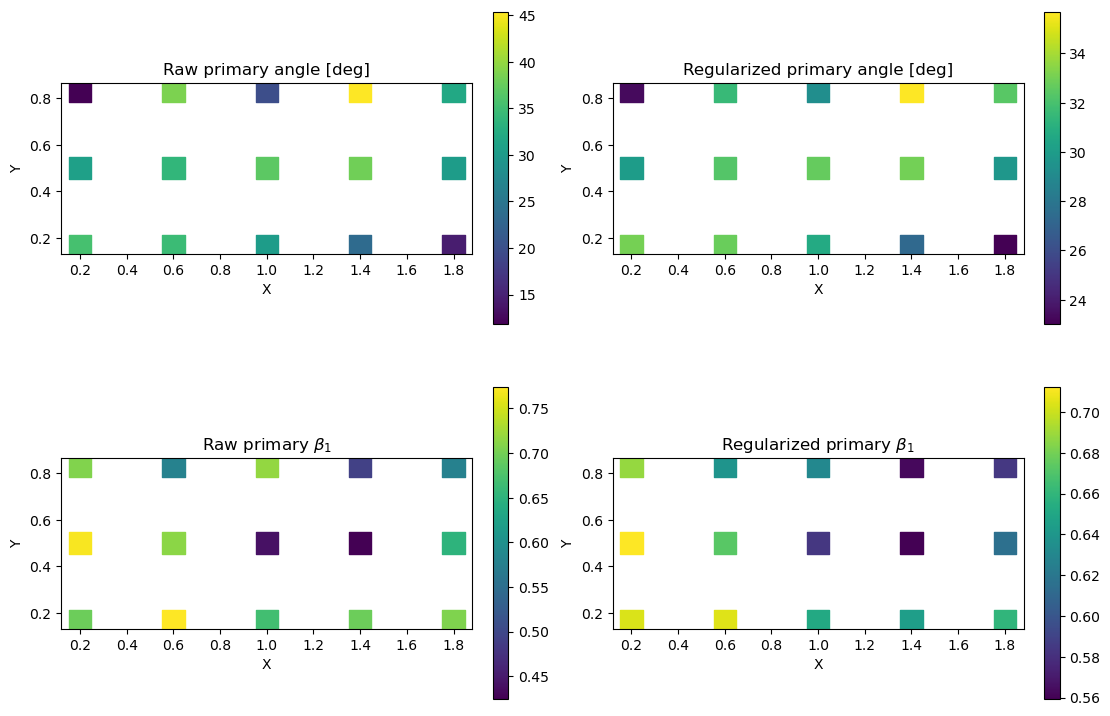

In [8]:
figure, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)
fields = [
    (
        np.rad2deg(vector_to_angle(family_direction_raw[:, 0])),
        "Raw primary angle [deg]",
    ),
    (
        primary_angle_regularized,
        "Regularized primary angle [deg]",
    ),
    (beta_raw[:, 0], r"Raw primary $\beta_1$"),
    (beta_regularized[:, 0], r"Regularized primary $\beta_1$"),
]

for axis, (field, title) in zip(axes.ravel(), fields, strict=True):
    scatter = axis.scatter(
        centroid[:, 0],
        centroid[:, 1],
        c=field,
        s=260,
        marker="s",
    )
    axis.set(title=title, xlabel="X", ylabel="Y", aspect="equal")
    figure.colorbar(scatter, ax=axis, shrink=0.85)

plt.show()

## 4. Finite-element comparison

Three models are loaded identically:

1. the raw two-family architecture;
2. the regularized two-family architecture;
3. a primary-family-only control.

This separates the effects of cross-family reinforcement and
spatial denoising.

In [9]:
fe_config = FiniteElementConfig(
    axial_extension=0.05,
    load_steps=3,
    gradient_tolerance=3.0e-7,
    maximum_iterations=450,
)

result_raw = solve_multifiber_displacement_controlled_equilibrium(
    mesh,
    family_direction_raw,
    beta_raw,
    material,
    fe_config,
)
result_regularized = solve_multifiber_displacement_controlled_equilibrium(
    mesh,
    family_direction_regularized,
    beta_regularized,
    material,
    fe_config,
    initial_displacement=result_raw.displacement,
)

primary_material = MultiFiberMaterialParameters(
    mu=material.mu,
    kappa=material.kappa,
    k1=(material.k1[0],),
    k2=(material.k2[0],),
    family_weights=(1.0,),
)
result_primary = solve_multifiber_displacement_controlled_equilibrium(
    mesh,
    family_direction_regularized[:, :1, :],
    beta_regularized[:, :1],
    primary_material,
    fe_config,
    initial_displacement=result_regularized.displacement,
)

comparison = {
    "raw two-family": result_raw,
    "regularized two-family": result_regularized,
    "primary only": result_primary,
}

print(
    f"{'model':>24} {'reaction_x':>14} {'std sigma_xx':>16} "
    f"{'min J':>12} {'residual':>12}"
)
for name, result in comparison.items():
    print(
        f"{name:>24} "
        f"{result.right_reaction[0]:14.8f} "
        f"{np.std(result.element_cauchy_stress[:, 0, 0]):16.8f} "
        f"{np.min(result.element_jacobian):12.8f} "
        f"{result.free_dof_residual_norm:12.3e}"
    )

                   model     reaction_x     std sigma_xx        min J     residual
          raw two-family     0.41780767       0.02573887   1.00142126    2.063e-07
  regularized two-family     0.40853515       0.00699267   1.00169106    1.916e-07
            primary only     0.42475065       0.00996420   1.00149033    7.705e-08


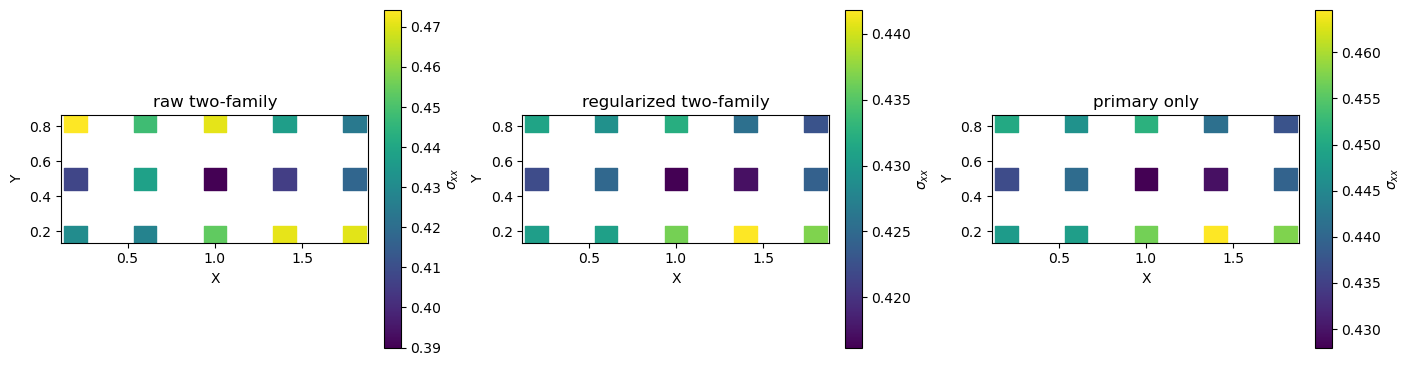

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for axis, (name, result) in zip(axes, comparison.items(), strict=True):
    scatter = axis.scatter(
        centroid[:, 0],
        centroid[:, 1],
        c=result.element_cauchy_stress[:, 0, 0],
        s=260,
        marker="s",
    )
    axis.set(
        title=name,
        xlabel="X",
        ylabel="Y",
        aspect="equal",
    )
    figure.colorbar(scatter, ax=axis, shrink=0.82, label=r"$\sigma_{xx}$")
plt.show()

## 5. Numerical and physical checks

In [11]:
checks = {
    "all FE solves converged": all(
        np.all(result.converged) for result in comparison.values()
    ),
    "positive Jacobians": all(
        np.min(result.element_jacobian) > 0.2
        for result in comparison.values()
    ),
    "small equilibrium residuals": all(
        result.free_dof_residual_norm < 1.0e-5
        for result in comparison.values()
    ),
    "balanced boundary reactions": all(
        np.linalg.norm(result.left_reaction + result.right_reaction)
        < 2.0e-5
        for result in comparison.values()
    ),
    "symmetric Cauchy stresses": all(
        np.max(
            np.abs(
                result.element_cauchy_stress
                - np.swapaxes(result.element_cauchy_stress, -1, -2)
            )
        )
        < 1.0e-12
        for result in comparison.values()
    ),
    "regularization reduces orientation roughness": (
        nematic_graph_roughness(
            mesh,
            family_direction_regularized[:, 0],
        )
        < nematic_graph_roughness(mesh, family_direction_raw[:, 0])
    ),
    "regularization reduces beta roughness": (
        scalar_graph_roughness(mesh, beta_regularized[:, 0])
        < scalar_graph_roughness(mesh, beta_raw[:, 0])
    ),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")
assert all(checks.values())

PASS — all FE solves converged
PASS — positive Jacobians
PASS — small equilibrium residuals
PASS — balanced boundary reactions
PASS — symmetric Cauchy stresses
PASS — regularization reduces orientation roughness
PASS — regularization reduces beta roughness


## 6. Export reproducible benchmark data

The NPZ archive stores the raw and regularized family fields plus
all three equilibrium solutions. The CSV table stores compact
comparison metrics suitable for regression tests and release notes.

In [12]:
output_data = REPOSITORY_ROOT / "results" / "data"
output_figures = REPOSITORY_ROOT / "results" / "figures"
output_data.mkdir(parents=True, exist_ok=True)
output_figures.mkdir(parents=True, exist_ok=True)

npz_path = output_data / "multiple_fiber_architecture_fields.npz"
np.savez_compressed(
    npz_path,
    nodes=mesh.nodes,
    elements=mesh.elements,
    centroids=centroid,
    family_direction_raw=family_direction_raw,
    family_direction_regularized=family_direction_regularized,
    beta_raw=beta_raw,
    beta_regularized=beta_regularized,
    displacement_raw=result_raw.displacement,
    displacement_regularized=result_regularized.displacement,
    displacement_primary=result_primary.displacement,
    stress_raw=result_raw.element_cauchy_stress,
    stress_regularized=result_regularized.element_cauchy_stress,
    stress_primary=result_primary.element_cauchy_stress,
    jacobian_raw=result_raw.element_jacobian,
    jacobian_regularized=result_regularized.element_jacobian,
    jacobian_primary=result_primary.element_jacobian,
)

csv_path = output_data / "multiple_fiber_architecture_metrics.csv"
metric_rows = []
for name, result in comparison.items():
    metric_rows.append(
        (
            name,
            result.right_reaction[0],
            np.mean(result.element_cauchy_stress[:, 0, 0]),
            np.std(result.element_cauchy_stress[:, 0, 0]),
            np.min(result.element_jacobian),
            result.free_dof_residual_norm,
        )
    )

with csv_path.open("w", encoding="utf-8") as stream:
    stream.write(
        "model,right_reaction_x,mean_sigma_xx,std_sigma_xx,"
        "minimum_jacobian,residual_norm\n"
    )
    for row in metric_rows:
        stream.write(
            f"{row[0]},{row[1]:.12g},{row[2]:.12g},"
            f"{row[3]:.12g},{row[4]:.12g},{row[5]:.12g}\n"
        )

summary_path = output_figures / "multiple_fiber_architecture_summary.png"
figure, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

scatter = axes[0, 0].scatter(
    centroid[:, 0],
    centroid[:, 1],
    c=primary_angle_regularized,
    s=260,
    marker="s",
)
axes[0, 0].set(
    title="Regularized primary angle [deg]",
    xlabel="X",
    ylabel="Y",
    aspect="equal",
)
figure.colorbar(scatter, ax=axes[0, 0])

scatter = axes[0, 1].scatter(
    centroid[:, 0],
    centroid[:, 1],
    c=secondary_angle_regularized,
    s=260,
    marker="s",
)
axes[0, 1].set(
    title="Regularized cross-family angle [deg]",
    xlabel="X",
    ylabel="Y",
    aspect="equal",
)
figure.colorbar(scatter, ax=axes[0, 1])

labels = list(comparison)
reactions = [comparison[name].right_reaction[0] for name in labels]
axes[1, 0].bar(labels, reactions)
axes[1, 0].set(
    ylabel="Right-boundary reaction",
    title="Integrated mechanical response",
)
axes[1, 0].tick_params(axis="x", rotation=18)

stress_std = [
    np.std(comparison[name].element_cauchy_stress[:, 0, 0])
    for name in labels
]
axes[1, 1].bar(labels, stress_std)
axes[1, 1].set(
    ylabel=r"Std. dev. of $\sigma_{xx}$",
    title="Stress heterogeneity",
)
axes[1, 1].tick_params(axis="x", rotation=18)

figure.savefig(summary_path, dpi=180)
plt.close(figure)

print(f"Saved: {npz_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {csv_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {summary_path.relative_to(REPOSITORY_ROOT)}")

Saved: results\data\multiple_fiber_architecture_fields.npz
Saved: results\data\multiple_fiber_architecture_metrics.csv
Saved: results\figures\multiple_fiber_architecture_summary.png


## 7. Interpretation and next stage

The multi-family formulation can represent a dominant load-bearing
direction together with a weaker cross-family, or approximate a
continuous orientation distribution through quadrature. The graph
regularizer reduces mesh-scale fluctuations while preserving
nematic symmetry.